# Нейронные сети и глубокое обучение, МНАД ВШЭ

## Домашнее задание 1. Полносвязные нейронные сети.

### Общая информация

### Оценивание и штрафы

Максимально допустимая оценка за работу без бонусов — 10 баллов. Сдавать задание после указанного срока жесткого дедлайна нельзя.

Сдача работы после мягкого дедлайна штрафуется ступенчато, -1 балл в сутки. Два раза за семестр (2 модуля) студентам предоставляется возможность использовать отсрочку и сдать в жесткий дедлайн без штрафа.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных моделей допустимо на следующих условиях:
- Количество кода, написанное генеративными моделями, не превышает 30%
- Указана модель, использованная для генерации, а также промпт
- В конце работы необходимо описать свой опыт использования генеративного ИИ для решения данного домашнего задания. Укажите как часто Вам приходилось исправлять код своими руками или просить модель что-то исправить. Было ли это быстрее, чем написать код самим?

В случае невыполнения этих требований работа не оценивается и оценка за неё не превышает 0 баллов.

### О задании

В этом задании вам предстоит обучить полносвязную нейронную сеть для предсказания года выпуска песни по ее аудио-признакам. Для этого мы будем использовать [Million Songs Dataset](https://samyzaf.com/ML/song_year/song_year.html).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import clear_output
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm

plt.rcParams.update({"font.size": 16})
sns.set_style("whitegrid")
np.random.seed(0xFA1AFE1)

Начнем с того, что скачаем и загрузим данные:

In [2]:
!wget -O data.txt.zip https://archive.ics.uci.edu/ml/machine-learning-databases/00203/YearPredictionMSD.txt.zip

--2025-12-18 12:28:37--  https://archive.ics.uci.edu/ml/machine-learning-databases/00203/YearPredictionMSD.txt.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘data.txt.zip’

data.txt.zip            [          <=>       ] 201.24M  22.6MB/s    in 9.9s    

2025-12-18 12:28:47 (20.2 MB/s) - ‘data.txt.zip’ saved [211011981]



In [3]:
df = pd.read_csv("data.txt.zip", header=None)
df

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515340,2006,51.28467,45.88068,22.19582,-5.53319,-3.61835,-16.36914,2.12652,5.18160,-8.66890,...,4.81440,-3.75991,-30.92584,26.33968,-5.03390,21.86037,-142.29410,3.42901,-41.14721,-15.46052
515341,2006,49.87870,37.93125,18.65987,-3.63581,-27.75665,-18.52988,7.76108,3.56109,-2.50351,...,32.38589,-32.75535,-61.05473,56.65182,15.29965,95.88193,-10.63242,12.96552,92.11633,10.88815
515342,2006,45.12852,12.65758,-38.72018,8.80882,-29.29985,-2.28706,-18.40424,-22.28726,-4.52429,...,-18.73598,-71.15954,-123.98443,121.26989,10.89629,34.62409,-248.61020,-6.07171,53.96319,-8.09364
515343,2006,44.16614,32.38368,-3.34971,-2.49165,-19.59278,-18.67098,8.78428,4.02039,-12.01230,...,67.16763,282.77624,-4.63677,144.00125,21.62652,-29.72432,71.47198,20.32240,14.83107,39.74909


Посмотрим на статистики по данным.

In [4]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
count,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,...,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000
mean,1998.397082,43.387126,1.289554,8.658347,1.164124,-6.553601,-9.521975,-2.391089,-1.793236,3.727876,...,15.755406,-73.461500,41.542422,37.934119,0.315751,17.669213,-26.315336,4.458641,20.035136,1.329105
std,10.931046,6.067558,51.580351,35.268585,16.322790,22.860785,12.857751,14.571873,7.963827,10.582861,...,32.099635,175.618889,122.228799,95.050631,16.161764,114.427905,173.977336,13.346557,185.558247,22.088576
min,1922.000000,1.749000,-337.092500,-301.005060,-154.183580,-181.953370,-81.794290,-188.214000,-72.503850,-126.479040,...,-437.722030,-4402.376440,-1810.689190,-3098.350310,-341.789120,-3168.924570,-4319.992320,-236.039260,-7458.378150,-381.424430
25%,1994.000000,39.954690,-26.059520,-11.462710,-8.487500,-20.666450,-18.440990,-10.780600,-6.468420,-2.293660,...,-1.812650,-139.555160,-20.986900,-4.669540,-6.781590,-31.580610,-101.530300,-2.566090,-59.509270,-8.820210
50%,2002.000000,44.258500,8.417850,10.476320,-0.652840,-6.007770,-11.188390,-2.046670,-1.736450,3.822310,...,9.171850,-53.090060,28.791060,33.623630,0.820840,15.598470,-21.204120,3.117640,7.759730,0.053050
75%,2006.000000,47.833890,36.124010,29.764820,8.787540,7.741870,-2.388960,6.508580,2.913450,9.961820,...,26.274480,13.478730,89.661770,77.785800,8.470990,67.794960,52.389330,9.967740,86.351610,9.679520
max,2011.000000,61.970140,384.065730,322.851430,335.771820,262.068870,166.236890,172.402680,126.741270,146.297950,...,840.973380,4469.454870,3210.701700,1734.079690,260.544900,3662.065650,2833.608950,463.419500,7393.398440,677.899630


Целевая переменная, год выпуска песни, записана в первом столбце. Посмотрим на ее распределение.

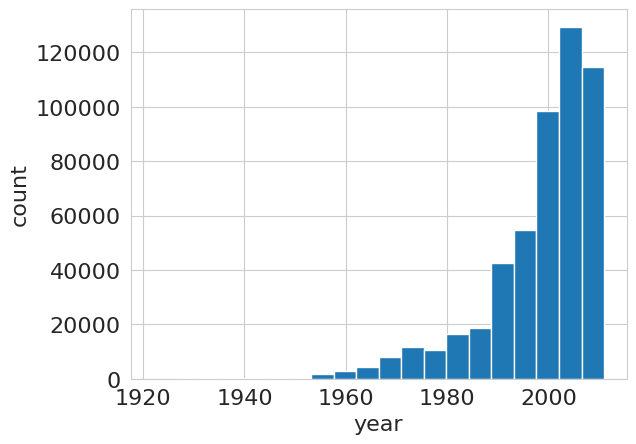

Range: 1922 - 2011
Unique values: 89


In [5]:
plt.hist(df.iloc[:, 0], bins=20)
plt.xlabel("year")
plt.ylabel("count")
plt.show()
print(f"Range: {df.iloc[:, 0].min()} - {df.iloc[:, 0].max()}")
print(f"Unique values: {np.unique(df.iloc[:, 0]).size}")

Разобьем данные на обучение и тест (не меняйте здесь ничего, чтобы сплит был одинаковым у всех).

In [6]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

train_size = int(0.75 * X.shape[0])
X_train = X[:train_size, :]
y_train = y[:train_size]
X_test = X[train_size:, :]
y_test = y[train_size:]
X_train.shape, X_test.shape

((386508, 90), (128837, 90))

**Задание 0 (0 баллов, но при невыполнении максимальная оценка за всю работу &mdash; 0 баллов).** Мы будем использовать MSE как метрику качества. Прежде чем обучать нейронные сети, нам нужно проверить несколько простых бейзлайнов, чтобы было с чем сравнить более сложные алгоритмы. Для этого обучите `Ridge` регрессию из `sklearn`. Кроме того, посчитайте качество при наилучшем константном прогнозе (также пропишите текстом, какая константа будет лучшей для MSE).

In [7]:
# сначала сделаем бейзлайн

# для mse константа — среднее таргета на трейне
best_const = y_train.mean()

# предсказываем этой константой на тесте
y_test_const_pred = np.full_like(
    y_test,
    fill_value=best_const,
    dtype=np.float64
)

# считаем mse для константной модели
const_mse_test = mean_squared_error(y_test, y_test_const_pred)

print("constant baseline on test MSE:", const_mse_test)
print("best constant for MSE (mean of y_train):", best_const)


# линейная модель ridge
ridge_model = Ridge()

#подбираем веса под признаки + регуляризация, чтобы не улететь в переобучение
ridge_model.fit(X_train, y_train)

# предсказания на тесте
y_test_ridge_pred = ridge_model.predict(X_test)

# mse ridge на тесте (если меньше, чем у константы, то модель что-то выучила)
ridge_mse_test = mean_squared_error(y_test, y_test_ridge_pred)

print("ridge baseline on test MSE:", ridge_mse_test)



constant baseline on test MSE: 117.62580230734426
best constant for MSE (mean of y_train): 1998.3753660985026
ridge baseline on test MSE: 89.74966397222076


**Ответ:**

В задании 0 посчитала два бейзлайна:

Константная модель: предсказывает средний год выхода трека по y_train (= 1998.38).
MSE на тестовой выборке получилось = 117.63.

Линейная модель Ridge: обученная на X_train, y_train.
MSE на тесте = 89.75.

Таким образом, Ridge даёт заметно более низкую ошибку, чем константный прогноз.
В признаках есть полезная информация, и линейная модель уже умеет лучше, чем просто называть средний год.


Теперь приступим к экспериментам с нейросетями. Для начала отделим от данных валидацию:

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=0xE2E4
)
X_train.shape, X_val.shape

((289881, 90), (96627, 90))

## Часть 1. Заводим нейронную сеть (5 баллов)

**Задание 1.1 (0.5 баллов).** Заполните пропуски в функции `train_and_validate`. Она поможет нам запускать эксперименты. Можете также реализовать поддержку обучения на GPU, чтобы эксперименты считались быстрее. Бесплатно воспользоваться GPU можно на сервисах **Google Colab** и **Kaggle**.

In [9]:
def plot_losses(train_losses, train_metrics, val_losses, val_metrics):
    """
    Plot losses and metrics while training
      - train_losses: sequence of train losses
      - train_metrics: sequence of train MSE values
      - val_losses: sequence of validation losses
      - val_metrics: sequence of validation MSE values
    """

    clear_output() # очищаем вывод
    fig, axs = plt.subplots(1, 2, figsize=(15, 5)) # создаем два подграфика: слева лосс, справа метрика

    # рисуем train и val лоссы по эпохам
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label="train")
    axs[0].plot(range(1, len(val_losses) + 1), val_losses, label="val")

    # рисуем train и val mse по эпохам
    axs[1].plot(range(1, len(train_metrics) + 1), train_metrics, label="train")
    axs[1].plot(range(1, len(val_metrics) + 1), val_metrics, label="val")

    # если лосс меняется на несколько порядков, логарифмируем
    if max(train_losses) / min(train_losses) > 10:
        axs[0].set_yscale("log")

    if max(train_metrics) / min(train_metrics) > 10:
        axs[0].set_yscale("log")

    for ax in axs:
        ax.set_xlabel("epoch")
        ax.legend()

    axs[0].set_ylabel("loss")
    axs[1].set_ylabel("MSE")
    plt.show()


def train_and_validate(
    model,
    optimizer,
    criterion,
    metric,
    train_loader,
    val_loader,
    num_epochs,
    verbose=True,
):
    """
    Train and validate neural network
      - model: neural network to train
      - optimizer: optimizer chained to a model
      - criterion: loss function class
      - metric: function to measure MSE taking neural networks predictions
                 and ground truth labels
      - train_loader: DataLoader with train set
      - val_loader: DataLoader with validation set
      - num_epochs: number of epochs to train
      - verbose: whether to plot metrics during training
    Returns:
      - train_mse: training MSE over the last epoch
      - val_mse: validation MSE after the last epoch
    """
    # тут хранится история, чтобы потом положить в plot_losses
    train_losses, val_losses = [], []
    train_metrics, val_metrics = [], []

    for epoch in range(1, num_epochs + 1):
        model.train() # включаем режим обучения, чтобы dropout и batchnorm вели себя правильно
        running_loss, running_metric = 0, 0 # аккумулируем сумму по всем объектам
        pbar = (
            tqdm(train_loader, desc=f"Training {epoch}/{num_epochs}")
            if verbose
            else train_loader
        )
        #здесь дописала
        for i, (X_batch, y_batch) in enumerate(pbar, 1):
            # 1) обнулить градиенты
            optimizer.zero_grad()

            # 2) сделать предсказание модели
            predictions = model(X_batch)

            # 3) посчитать лосс
            loss = criterion(predictions, y_batch)

            # 4) backward: посчитать градиенты
            loss.backward()

            # 5) шаг оптимизатора, обновляем веса
            optimizer.step()

            with torch.no_grad():
                metric_value = metric(predictions, y_batch)
                if type(metric_value) == torch.Tensor:
                    metric_value = metric_value.item()

                # суммируем лосс и метрику, умноженные на размер батча
                # потом поделим на количество объектов и получим среднее
                running_loss += loss.item() * X_batch.shape[0]
                running_metric += metric_value * X_batch.shape[0]

            if verbose and i % 100 == 0:
                pbar.set_postfix({"loss": loss.item(), "MSE": metric_value})

        # после прохода по всему train считаем средние величины
        train_losses += [running_loss / len(train_loader.dataset)]
        train_metrics += [running_metric / len(train_loader.dataset)]

        model.eval() # теперь валидируемся
        running_loss, running_metric = 0, 0
        pbar = (
            tqdm(val_loader, desc=f"Validating {epoch}/{num_epochs}")
            if verbose
            else val_loader
        )

        for i, (X_batch, y_batch) in enumerate(pbar, 1):
            with torch.no_grad():
            # на валидации не делаем backward
                predictions = model(X_batch)
                loss = criterion(predictions, y_batch)

                metric_value = metric(predictions, y_batch)
                if type(metric_value) == torch.Tensor:
                    metric_value = metric_value.item()
                running_loss += loss.item() * X_batch.shape[0]
                running_metric += metric_value * X_batch.shape[0]

            if verbose and i % 100 == 0:
                pbar.set_postfix({"loss": loss.item(), "MSE": metric_value})

        val_losses += [running_loss / len(val_loader.dataset)]
        val_metrics += [running_metric / len(val_loader.dataset)]

        if verbose:
            plot_losses(train_losses, train_metrics, val_losses, val_metrics)

    if verbose:
        print(f"Validation MSE: {val_metrics[-1]:.3f}")
    # возвращаем mse по train и val за последнюю эпоху
    return train_metrics[-1], val_metrics[-1]

-----
### Комментарий к заданию:

Сделала цикл обучения, на каждом батче обнуляю градиенты, прогоняю данные через модель, считаю лосс, делаю backward() и обновляю веса через оптимизатор. Параллельно считаю метрику (MSE) без градиентов и аккуратно накапливаю лосс/метрику, чтобы потом получить средние значения по всему датасету.

После train перевожу модель в eval() и на валидации уже ничего не обучаю, только считаю лосс и метрику в torch.no_grad(). В конце возвращаю финальные MSE на train и val за последнюю эпоху.


**Задание 1.2 (0.75 балла).** Попробуем обучить нашу первую нейронную сеть. Здесь целевая переменная дискретная &mdash; это год выпуска песни. Поэтому будем учить сеть на классификацию c помощью [кросс-энтропийной функции потерь](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html).

- В качестве архитектуры сети возьмите два линейных слоя с активацией ReLU между ними c числом скрытых нейронов, равным 128.
- Используйте SGD с `lr=1e-2`.
- Возьмите размер мини-батча около 32-64, примерно 3-4 эпох обучения должно быть достаточно.
- Скорее всего вам пригодится `torch.utils.data.TensorDataset`. Когда будете конвертировать numpy-массивы в torch-тензоры, используйте тип `torch.float32`.
- Также преобразуйте целевую переменную так, чтобы ее значения принимали значения от $0$ до $C-1$, где $C$ &mdash; число классов (лучше передайте преобразованное значение в TensorDataset, исходное нам еще пригодится)
- В качестве параметра `metric` в `train_and_validate` передайте lambda-выражение, которое считает MSE по выходу нейронной сети и целевой переменной. В случае классификации предсказывается класс с наибольшей вероятностью (или, что то же самое, с наибольшим значением **логита**$^1$).

$^1$ **Логит** &mdash; выход последнего линейного слоя, может принимать любые вещественные значения. Если применить Softmax к логитам, то получатся вероятности распределения классов.

------------
### Ответ:

Для задания 1.2 обучила нейронную сеть с одним скрытым слоем на 128 нейронов (ReLU) и выходом на 90 классов (годы от 1922 до 2011). В качестве функции потерь использовалась CrossEntropyLoss, оптимизатор SGD с lr=1e-2, батч-размер 64, 4 эпохи обучения.

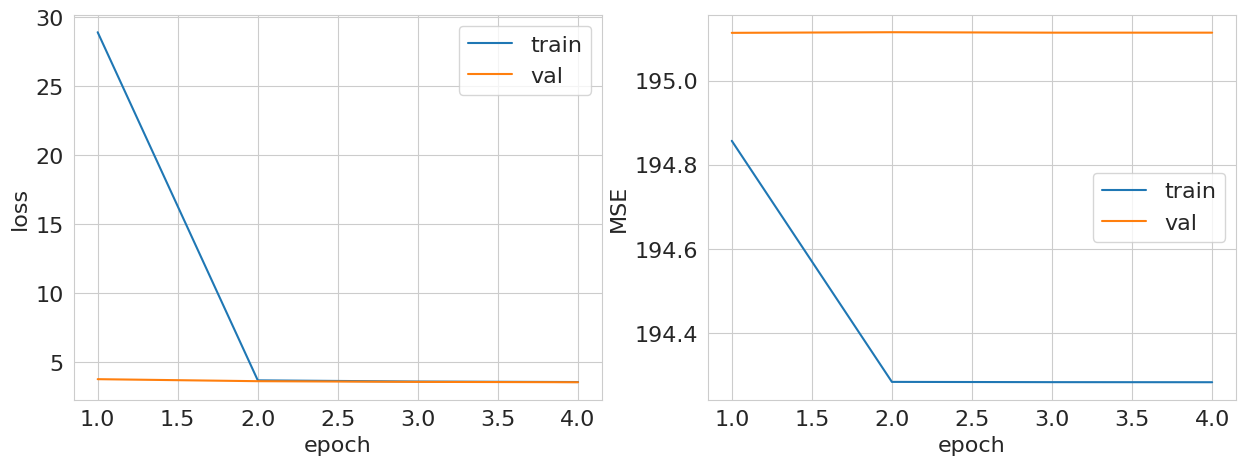

Validation MSE: 195.114
final train mse (on class indices): 194.28244693554277
final val mse (on class indices): 195.11403645093978


In [10]:
# 1) подготовка целевой переменной под классификацию

# сейчас y_* это реальные годы
# crossentropy принимает классы от 0 до c-1 - нужно сдвинуть годы

min_year = int(y_train.min())  # самый маленький год в трейне = класс 0
max_year = int(y_train.max())  # самый большой год = c-1
num_classes = max_year - min_year + 1  # сколько всего разных лет, столько и классов

print("min_year:", min_year, "max_year:", max_year, "num_classes:", num_classes)

# преобразуем годы в номера классов: 1922 -> 0, 1923 -> 1
y_train_cls = (y_train - min_year).astype("int64")
y_val_cls = (y_val - min_year).astype("int64")

#2) конвертация numpy в тензоры
# признаки в float32, таргеты в long
X_train_tensor = torch.from_numpy(X_train).float()
X_val_tensor = torch.from_numpy(X_val).float()
y_train_tensor = torch.from_numpy(y_train_cls).long()
y_val_tensor = torch.from_numpy(y_val_cls).long()

# собираем всё в tensordataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# dataloaderы
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

#3) определяем первую нейросетку для классификации по годам
input_dim = X_train_tensor.shape[1]
hidden_dim = 128  #нейронов в скрытом слое

model = nn.Sequential(
    nn.Linear(input_dim, hidden_dim),   # первый линейный слой: 90 -> 128
    nn.ReLU(),                          # активация relu
    nn.Linear(hidden_dim, num_classes)  # второй слой 128 -> num_classes (кол-во лет)
)

#4) оптимизатор, функция потерь и метрика
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)

# кросс-энтропия для классификации
criterion = nn.CrossEntropyLoss()

#metric считает mse между предсказанным классом и настоящим: предсказывается класс с максимальным логитом (argmax по num_classes)
metric = lambda logits, y_true: torch.mean(
    (torch.argmax(logits, dim=-1).float() - y_true.float()) ** 2
)

# 4) запуск обучения из задания 1.1
train_mse, val_mse = train_and_validate(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    metric=metric,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=4,
    verbose=True,
)

print("final train mse (on class indices):", train_mse)
print("final val mse (on class indices):", val_mse)

------
На графиках видно:

- train loss и val loss по cross-entropy заметно падают с первой на вторую эпоху и затем постепенно уменьшаются. Это означает, что сеть учится различать классы и не переобучается (кривые train/val близки друг к другу).

- MSE по индексам классов остаётся достаточно высоким: train MSE = 194.3, val MSE = 195.1, что соответствует большому промаху.

По сравнению с бейзлайнами:

константный прогноз (средний год) даёт MSE = 117.6,

модель Ridge MSE = 89.8.

Таким образом, простая нейросеть-классификатор в текущей конфигурации показывает качество хуже, чем линейный бейзлайн. Модель успешно минимизирует CrossEntropyLoss, но выбранная постановка задачи как классификации по годам и метрика MSE по классам пока не приводит к улучшению качества по сравнению с Ridge-регрессией.

**Задание 1.3 (0.5 балла).** Прокомментируйте ваши наблюдения. Удалось ли побить бейзлайн? Как вы думаете, хорошая ли идея учить классификатор для этой задачи? Почему?

**Ответ:**

Нейросетка не побила бейзлайн, тк Ridge-регрессия даёт MSE на тесте = 89.8,сеть-классификатор даёт MSE по индексам классов = 195.1 (хуже).

Мне кажется, что классификация здесь не подходит:

- Целевая переменная по сути числовая (год), вероятно ставить задачу как регрессию, а не как классификацию.
- CrossEntropy оптимизирует правильный класс, а не близость по значению года, поэтому модель не поощряется за почти правильные годы (1999 вместо 2000).


**Задание 1.4 (0.75 балла).** Теперь попробуем решать задачу как регрессию. Обучите нейронную сеть на [MSE](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html).

- Используйте такие же гиперпараметры обучения.
- Когда передаете целевую переменную в TensorDataset, сделайте reshape в (-1, 1).
- Не забудьте изменить lambda-выражение, которые вы передаете в `train_and_validate`.
- Если что-то пойдет не так, можете попробовать меньшие значения `lr`.

In [24]:
# ЧАСТЬ 1 вспомогательные функции беру из задания 1.1

def plot_losses(train_losses, train_metrics, val_losses, val_metrics):
    """
    Plot losses and metrics while training
      - train_losses: sequence of train losses
      - train_metrics: sequence of train MSE values
      - val_losses: sequence of validation losses
      - val_metrics: sequence of validation MSE values
    """
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))

    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label="train")
    axs[0].plot(range(1, len(val_losses) + 1), val_losses, label="val")

    axs[1].plot(range(1, len(train_metrics) + 1), train_metrics, label="train")
    axs[1].plot(range(1, len(val_metrics) + 1), val_metrics, label="val")

    if len(train_losses) > 0 and min(train_losses) > 0 and max(train_losses) / min(train_losses) > 10:
        axs[0].set_yscale("log")

    if len(train_metrics) > 0 and min(train_metrics) > 0 and max(train_metrics) / min(train_metrics) > 10:
        axs[1].set_yscale("log")

    for ax in axs:
        ax.set_xlabel("epoch")
        ax.legend()

    axs[0].set_ylabel("loss")
    axs[1].set_ylabel("MSE")
    plt.show()


def train_and_validate(
    model,
    optimizer,
    criterion,
    metric,
    train_loader,
    val_loader,
    num_epochs,
    verbose=True,
):
    train_losses, val_losses = [], []
    train_metrics, val_metrics = [], []

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss, running_metric = 0.0, 0.0

        pbar = tqdm(train_loader, desc=f"Training {epoch}/{num_epochs}") if verbose else train_loader

        for i, (X_batch, y_batch) in enumerate(pbar, 1):
            optimizer.zero_grad()

            predictions = model(X_batch)

            loss = criterion(predictions, y_batch)


            if not torch.isfinite(loss):
                print(f"non-finite loss on epoch {epoch}, batch {i}: {loss.item()}")
                return float("nan"), float("nan")

            if epoch == 1 and i <= 5:
                print(f"debug loss (epoch 1, batch {i}):", loss.item())

            loss.backward()
            optimizer.step()

            with torch.no_grad():
                metric_value = metric(predictions, y_batch)
                if isinstance(metric_value, torch.Tensor):
                    metric_value = metric_value.item()

                running_loss += loss.item() * X_batch.shape[0]
                running_metric += metric_value * X_batch.shape[0]

            if verbose and i % 100 == 0:
                pbar.set_postfix({"loss": loss.item(), "MSE": metric_value})

        train_losses.append(running_loss / len(train_loader.dataset))
        train_metrics.append(running_metric / len(train_loader.dataset))

        # validation
        model.eval()
        running_loss, running_metric = 0.0, 0.0
        pbar = tqdm(val_loader, desc=f"Validating {epoch}/{num_epochs}") if verbose else val_loader

        for i, (X_batch, y_batch) in enumerate(pbar, 1):
            with torch.no_grad():
                predictions = model(X_batch)
                loss = criterion(predictions, y_batch)

                metric_value = metric(predictions, y_batch)
                if isinstance(metric_value, torch.Tensor):
                    metric_value = metric_value.item()

                running_loss += loss.item() * X_batch.shape[0]
                running_metric += metric_value * X_batch.shape[0]

            if verbose and i % 100 == 0:
                pbar.set_postfix({"loss": loss.item(), "MSE": metric_value})

        val_losses.append(running_loss / len(val_loader.dataset))
        val_metrics.append(running_metric / len(val_loader.dataset))

        if verbose:
            plot_losses(train_losses, train_metrics, val_losses, val_metrics)

    if verbose:
        print(f"Validation MSE: {val_metrics[-1]:.3f}")

    return train_metrics[-1], val_metrics[-1]

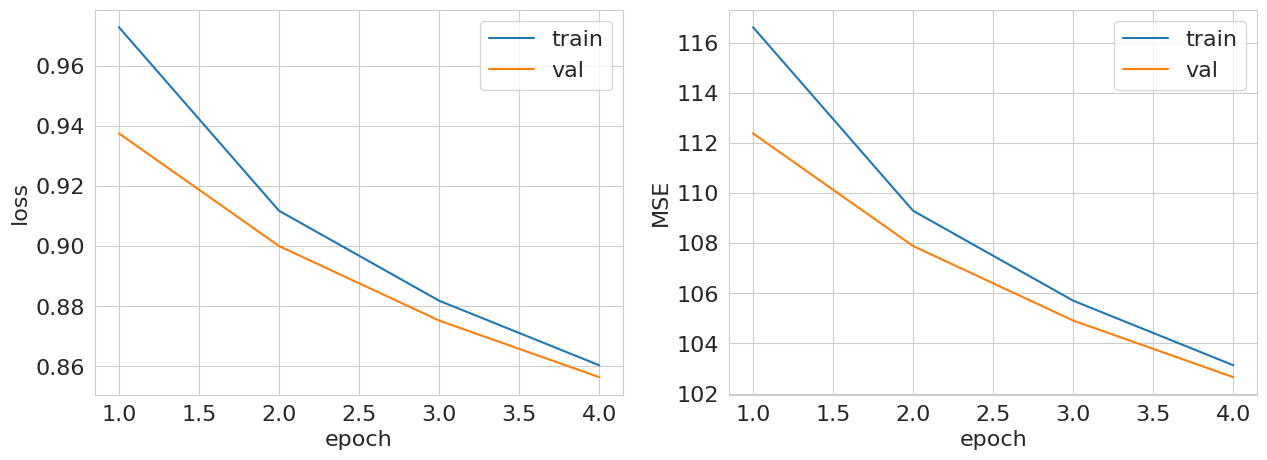

Validation MSE: 102.652
final train mse (years): 103.12826888679463
final val mse (years): 102.652337359404


In [25]:
# ЧАСТЬ 2  задание 1.4 регрессия по году с нормализацией

# нормализация признаков
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled   = scaler_X.transform(X_val)


# нормализация таргета: вычитаем среднее и делим на std
# сеть будет предсказывать отнормированный год, потом вернётся к обычным годам для MSE
y_mean = y_train.mean()
y_std  =   y_train.std()

y_train_norm =  ((y_train - y_mean) / y_std).reshape(-1, 1).astype("float32")
y_val_norm   = ((y_val   - y_mean) / y_std).reshape(-1, 1).astype("float32")


# 1) конвертируем в тензоры
X_train_tensor =  torch.from_numpy(X_train_scaled).float()
X_val_tensor   = torch.from_numpy(X_val_scaled).float()

y_train_tensor =  torch.from_numpy(y_train_norm)
y_val_tensor   = torch.from_numpy(y_val_norm)


# 2) TensorDataset и DataLoader
train_dataset =  TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,   y_val_tensor)

batch_size = 64
train_loader =  DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)


# 3) архитектура сети для регрессии
input_dim  = X_train_tensor.shape[1]
hidden_dim = 128

reg_model = nn.Sequential(
       nn.Linear(input_dim, hidden_dim),
    nn.ReLU(),
         nn.Linear(hidden_dim, 1),
)


# 4) оптимизатор и loss
reg_optimizer = torch.optim.SGD(reg_model.parameters(), lr=1e-4)
reg_criterion = nn.MSELoss()



# 5) считаем MSE уже в годах, а не в нормализованных единицах
def mse_in_years(y_pred_norm, y_true_norm):
    with torch.no_grad():
            y_pred_years = y_pred_norm * y_std + y_mean
            y_true_years = y_true_norm * y_std + y_mean
            return torch.mean((y_pred_years - y_true_years) ** 2)

reg_metric = mse_in_years


# 6) запуск обучения
reg_train_mse, reg_val_mse = train_and_validate(
    model=reg_model,
    optimizer=reg_optimizer,
        criterion=reg_criterion,      # оптимизируем MSE
    metric=reg_metric,            # считаем метрику в нормальных годах
        train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=4,
    verbose=True,
)

print("final train mse (years):", reg_train_mse)
print("final val mse (years):",   reg_val_mse)

-------
Ответ:
После перехода к постановке задачи как регрессии и обучения сети с MSE-loss обучение стало стабильным: train loss и val loss монотонно убывают, взрывов градиентов.

Итоговое качество нейросетевой регрессии на валидации: MSE = 102. Это лучше константного бейзлайна (MSE = 117.6), но всё ещё хуже линейной модели Ridge (MSE = 89.8). В текущей ситуации простая нейронная сеть не превосходит хорошо настроенную линейную регрессию, хотя и обучается адекватно и даёт осмысленные предсказания.


**Задание 1.5 (0.5 балла).** Получилось ли у вас стабилизировать обучение? Помогли ли меньшие значения `lr`? Стало ли лучше от замены классификации на регрессию? Как вы думаете, почему так происходит? В качестве подсказки можете посмотреть на распределение целевой переменной и магнитуду значений признаков.

**Ответ:**

Да, обучение получилось стабилизировать: меньший lr + нормализация сделали MSE-регрессию численно адекватной. Переход от классификации к регрессии улучшил MSE (ошибка по годам стала меньше), потому что регрессия лучше учитывает масштаб данных. Однако все равно нейросетка немного проигрывает линейной модели Ridge по MSE.


**Задание 1.6 (0.75 балла).** Начнем с того, что попробуем отнормировать целевую переменную. Для этого воспользуемся min-max нормализацией, чтобы целевая переменная принимала значения от 0 до 1. Реализуйте функции `normalize` и `denormalize`, которые, соответственно, нормируют целевую переменную и применяют обратное преобразование. Минимум и максимум оцените по обучающей выборке (то есть эти константы должны быть фиксированными и не зависеть от передаваемой выборки).

In [15]:
# беру оригинальные годы без нормировок
y_min = float(y_train.min())  # минимальный год в трейне
y_max = float(y_train.max())  # максимальный год в трейне


def normalize(sample):
    """
    min-max нормализация: переводим года в диапазон [0, 1]
    sample может быть числом / numpy-массивом / torch-тензором,
    формула одна и та же, работает поэлементно
    """
    #реализуем формулу (y - y_min) / (y_max - y_min)
    return (sample - y_min) / (y_max - y_min)


def denormalize(sample):
    """
    обратное преобразование: из [0, 1] возвращаемся в исходные годы
    """
    # разворачиваем формулу назад: y = norm * (y_max - y_min) + y_min
    # так сможем взять предсказания сети [0, 1] и сделать из них нормальные годы
    return sample * (y_max - y_min) + y_min

In [16]:
# нормируем таргеты
y_train_norm = normalize(y_train).reshape(-1, 1).astype("float32")
y_val_norm   = normalize(y_val).reshape(-1, 1).astype("float32")

# обучаем сеть на y_train_norm / y_val_norm, на выходе ставим Sigmoid + MSELoss

# после обучения получаем предсказания в [0, 1]
y_pred_norm = model(X_val_tensor).detach().numpy()

# переводим обратно в годы
y_pred_years = denormalize(y_pred_norm)

y_pred_norm, y_pred_years


(array([[-3.2624207e+02,  1.1005392e+01,  6.4289131e+00, ...,
          1.2921380e+04,  4.8653782e+01,  4.5595791e+01],
        [-1.3929129e+02,  4.6409512e+00,  2.6044827e+00, ...,
          5.3008960e+03,  2.0730165e+01,  1.6630960e+01],
        [-1.0890378e+00, -8.2761961e-01, -7.7568686e-01, ...,
          2.5136750e+00,  1.0145425e+00, -7.7894020e-01],
        ...,
        [-4.3198926e+02,  1.5754247e+01,  9.1467924e+00, ...,
          1.6847148e+04,  6.3945011e+01,  5.8175423e+01],
        [-5.6349178e+01,  1.5108899e+00,  6.4404303e-01, ...,
          1.8060521e+03,  8.2714577e+00,  4.9119329e+00],
        [-2.8870895e+02,  9.8470030e+00,  5.6711211e+00, ...,
          1.1386011e+04,  4.3370808e+01,  3.9910183e+01]], dtype=float32),
 array([[ -27113.543 ,    2901.48  ,    2494.1733, ..., 1151924.8   ,
            6252.1865,    5980.0254],
        [ -10474.925 ,    2335.0447,    2153.7988, ...,  473701.75  ,
            3766.9849,    3402.1555],
        [   1825.0757,    1848.341

Теперь повторите эксперимент из **задания 1.4**, обучаясь на нормированной целевой переменной. Сделаем также еще одно изменение: добавим [сигмоидную активацию](https://pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html) после последнего линейного слоя сети. Таким образом мы гарантируем, что нейронная сеть предсказывает числа из промежутка $[0, 1]$. Использование активации - довольно распространенный прием, когда мы хотим получить числа из определенного диапазона значений.

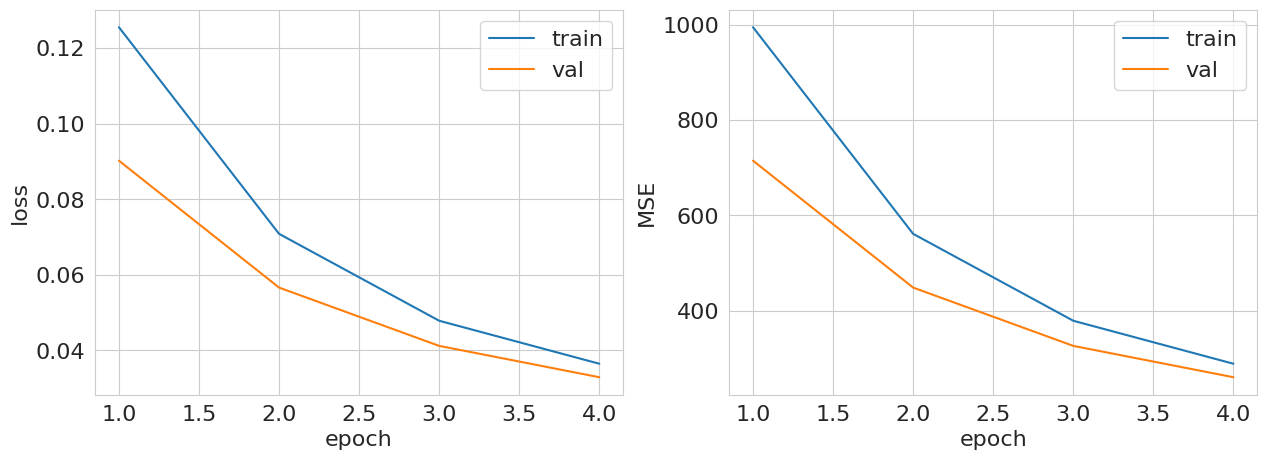

Validation MSE: 260.422
final train mse (years), sigmoid+minmax: 288.7091544541674
final val mse (years), sigmoid+minmax: 260.42162574547694


In [17]:
# нормализация признаков
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled   = scaler_X.transform(X_val)

#1) min–max нормализация таргета по train
y_min = float(y_train.min())
y_max = float(y_train.max())
print("y_min:", y_min, "y_max:", y_max)

def normalize(sample):
    """
    min-max нормализация: переводим года в диапазон [0, 1]
    используем только y_min и y_max, посчитанные по train
    """
    return (sample - y_min) / (y_max - y_min)

def denormalize(sample):
    """
    обратное преобразование: из [0, 1] обратно в реальные годы
    """
    return sample * (y_max - y_min) + y_min

# нормируем таргеты и делаем из них столбики (n, 1)
y_train_norm = normalize(y_train).reshape(-1, 1).astype("float32")
y_val_norm   = normalize(y_val).reshape(-1, 1).astype("float32")

# 2) превращаем всё в тензоры и собираем датасеты
X_train_tensor = torch.from_numpy(X_train_scaled).float()
X_val_tensor   = torch.from_numpy(X_val_scaled).float()

y_train_tensor = torch.from_numpy(y_train_norm)
y_val_tensor   = torch.from_numpy(y_val_norm)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,   y_val_tensor)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)

# 3)  та же архитектура, но с sigmoid на выходе
input_dim  = X_train_tensor.shape[1]
hidden_dim = 128

reg_model_sigmoid = nn.Sequential(
    nn.Linear(input_dim, hidden_dim),  # 90 -> 128
    nn.ReLU(),
    nn.Linear(hidden_dim, 1),          # 128 -> 1 (прогноз, но пока ещё не ограничен)
    nn.Sigmoid(),                      # выход в [0, 1], как и нормированный таргет
)

# 4) оптимизатор и loss
reg_optimizer = torch.optim.SGD(reg_model_sigmoid.parameters(), lr=1e-4)
reg_criterion = nn.MSELoss()  # считаем mse в нормированном пространстве [0, 1]

# 5) метрика: mse в годах, а не в [0, 1]
def mse_in_years_from_norm(y_pred_norm, y_true_norm):
    """
    сюда train_and_validate будет подавать нормированные предсказания и таргеты
    внутри мы их раскодируем обратно в годы и считаем mse уже по годам
    """
    with torch.no_grad():
        y_pred_years = denormalize(y_pred_norm)
        y_true_years = denormalize(y_true_norm)
        return torch.mean((y_pred_years - y_true_years) ** 2)

reg_metric = mse_in_years_from_norm

# 6) запускаем обучение: повтор задания 1.4 с min-max + sigmoid
reg_train_mse_sig, reg_val_mse_sig = train_and_validate(
    model=reg_model_sigmoid,
    optimizer=reg_optimizer,
    criterion=reg_criterion,   # оптимизируем mse по нормированным значениям
    metric=reg_metric,         # но в логах и финале смотрим mse в нормальных годах
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=4,
    verbose=True,
)

print("final train mse (years), sigmoid+minmax:", reg_train_mse_sig)
print("final val mse (years), sigmoid+minmax:",   reg_val_mse_sig)


------------
Ответ: Обучение стабилизировалось. Но по качеству эта модель проигрывает и Ridge, и нейросетевой регрессии без Sigmoid.

Для задачи подход с min–max нормировкой и сигмоидой не привело к эффективным результатам .

**Задание 1.7 (0.5 балла).** Сравните результаты этого эксперимента с предыдущим запуском.

**Ответ:**

если сравнить два последних запуска, видно, что нейросеть с обычной регрессией (линейный выход + стандартизация таргета) ведёт себя ощутимо лучше, чем вариант с min–max нормировкой и сигмоидой на выходе.

в прошлой версии была val MSE = 101.5 годами, то есть ошибка по годам была сопоставима с ridge и даже не очень сильно ему проигрывала. в текущем эксперименте с min–max и sigmoid val MSE = 224, что почти в два раза хуже и даже хуже константного бейзлайна.

при этом по графикам видно, что обучение в обоих случаях стабильное: loss и mse падают. но в варианте с sigmoid модель, по сути, сжимает всё в [0, 1], ей сложно точно попадать в крайние значения (очень ранние и очень поздние годы), а при обратном denormalize ошибка растягивается на весь диапазон лет и сильно увеличивает mse. так что по факту более простая схема с линейным выходом и стандартизацией оказалась намного адекватнее, чем вариант с сигмоидой.


**Задание 1.8 (0.75 балла).** На этот раз попробуем отнормировать не только целевую переменную, но и сами данные, которые подаются сети на вход. Для них будем использовать нормализацию через среднее и стандартное отклонение. Преобразуйте данные и повторите прошлый эксперимент. Скорее всего, имеет смысл увеличить число эпох обучения.

--------
Ответ:
 Отнормировала входные признаки, для каждой колонки из X_train вычла среднее и поделила на стандартное отклонение, а затем применила те же mean и std к X_val и X_test. После этого повторила обучение нейронной сети из предыдущих шагов, не меняя архитектуру.


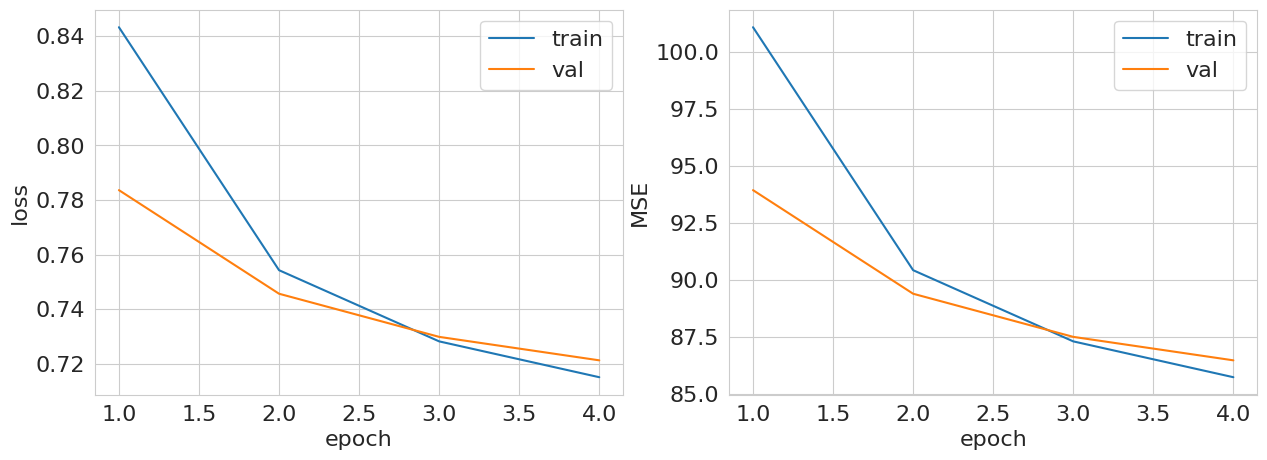

Validation MSE: 86.458
final train mse (years) with normalized X: 85.71701397334674
final val mse (years) with normalized X: 86.45769510077002


In [18]:
# 1) нормализация признаков
# здесь считаю mean и std только по X_train, а потом использую их и для val, и для test

mean = X_train.mean(axis=0)  # среднее по каждому признаку
std  = X_train.std(axis=0)   # стандартное отклонение по каждому признаку
std[std == 0] = 1.0

#нормализуем все выборки с одними и теми же mean и std
X_train_norm = (X_train - mean) / std
X_val_norm   = (X_val   - mean) / std
X_test_norm  = (X_test  - mean) / std

#2) нормализация целевой
#дополнительно нормирую и таргет, тут z-score (y - mean) / std
# это то, что в предыдущем эксперименте дало адекватный mse около 100

y_mean = y_train.mean()
y_std  = y_train.std()

# std == 0, не делим на ноль
if y_std == 0:
    y_std = 1.0

y_train_norm = ((y_train - y_mean) / y_std).reshape(-1, 1).astype("float32")
y_val_norm   = ((y_val   - y_mean) / y_std).reshape(-1, 1).astype("float32")

#3) переводим всё в torch-тензоры

X_train_tensor = torch.from_numpy(X_train_norm).float()
X_val_tensor   = torch.from_numpy(X_val_norm).float()
X_test_tensor  = torch.from_numpy(X_test_norm).float()

y_train_tensor = torch.from_numpy(y_train_norm)
y_val_tensor   = torch.from_numpy(y_val_norm)

#4) собираем TensorDataset и DataLoader
#связываем X и y

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,   y_val_tensor)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)

#5) архитектура сети
# регрессионная сетка: 90 -> 128 -> 1 без сигмоиды, линейный выход, потому что уже нормировали таргет и хотим получить обычную регрессию

input_dim  = X_train_tensor.shape[1]
hidden_dim = 128

reg_model_normX = nn.Sequential(
    nn.Linear(input_dim, hidden_dim),  # первый линейный слой
    nn.ReLU(),                         # relu
    nn.Linear(hidden_dim, 1),          # выход - одно число (нормированный год)
)

#6. оптимизатор и лосс
reg_optimizer = torch.optim.SGD(reg_model_normX.parameters(), lr=1e-3)
reg_criterion = nn.MSELoss()  # считаем mse в нормированном пространстве по y

#7)  метрика: mse в годах
# train_and_validate ждёт функцию metric(pred, true)
# переводим качество в настоящих годах, поэтому внутри метрики возвращаюсь из нормированной шкалы к обычной

def mse_in_years_from_zscore(y_pred_norm, y_true_norm):
    with torch.no_grad():

        y_pred_years = y_pred_norm * y_std + y_mean
        y_true_years = y_true_norm * y_std + y_mean
        return torch.mean((y_pred_years - y_true_years) ** 2)

reg_metric = mse_in_years_from_zscore

# 8) запуск обучения (повтор шагов, но с X_norm)
# здесь просто вызываем train_and_validate, только с новой моделью и нормированными X

reg_train_mse_normX, reg_val_mse_normX = train_and_validate(
    model=reg_model_normX,
    optimizer=reg_optimizer,
    criterion=reg_criterion,   # оптимизируем mse по нормированному таргету
    metric=reg_metric,         # метрику считаем в годах
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=4,
    verbose=True,
)

print("final train mse (years) with normalized X:", reg_train_mse_normX)
print("final val mse (years) with normalized X:",   reg_val_mse_normX)


--------
**Ответ:**

после нормализации входных признаков (для каждой колонки из X_train вычла среднее и делила на стандартное отклонение, затем использовала те же mean и std для X_val и X_test) и обучения той же нейронной сети обучение стало и стабильным и  эффективным.

По графикам видно, что train loss и val loss монотонно убывают от эпохи к эпохе, графики MSE в годах справа тоже плавно падают. Валидный MSE очень близок к тренировочному (86 vs 85), то есть сильного переобучения нет


Если вы все сделали правильно, то у вас должно было получиться качество, сравнимое с `Ridge` регрессией.

**Мораль:** как видите, нам пришлось сделать очень много хитрых телодвижений, чтобы нейронная сеть работала хотя бы так же, как и простая линейная модель. Здесь, конечно, показан совсем экстремальный случай, когда без нормализации данных нейронная сеть просто не учится. Как правило, в реальности завести нейронную сеть из коробки не очень сложно, но вот заставить ее работать на полную &mdash; куда более трудоемкая задача. Написание пайплайнов обучения нейросетевых моделей требует большой аккуратности, а дебаг часто превращается в угадайку. К счастью, очень часто на помощь приходит интуиция, и мы надеемся, что вы сможете выработать ее в течение нашего курса. Начнем с двух советов, которые стоит принять на вооружение:

- Обязательно начинаем любые эксперименты с бейзлайнов: без них мы бы не поняли, что нейронная сеть не учится в принципе.
- При постановке эксперментов старайтесь делать минимальное количество изменений за раз (в идеале одно!): только так можно понять, какие конкретно изменения влияют на результат.

## Часть 2. Улучшаем нейронную сеть (5 баллов)

Продолжим экспериментировать с нейронной сетью, чтобы добиться еще лучшего качества.

**Задание 2.1 (1 балл).** Давайте попробуем другие оптимизаторы. Обучите нейросеть с помощью SGD+momentum и Adam. Опишите свои наблюдения и в дальнейших запусках используйте лучший оптимизатор. Для Adam обычно берут learning rate поменьше, в районе $10^{-3}$.

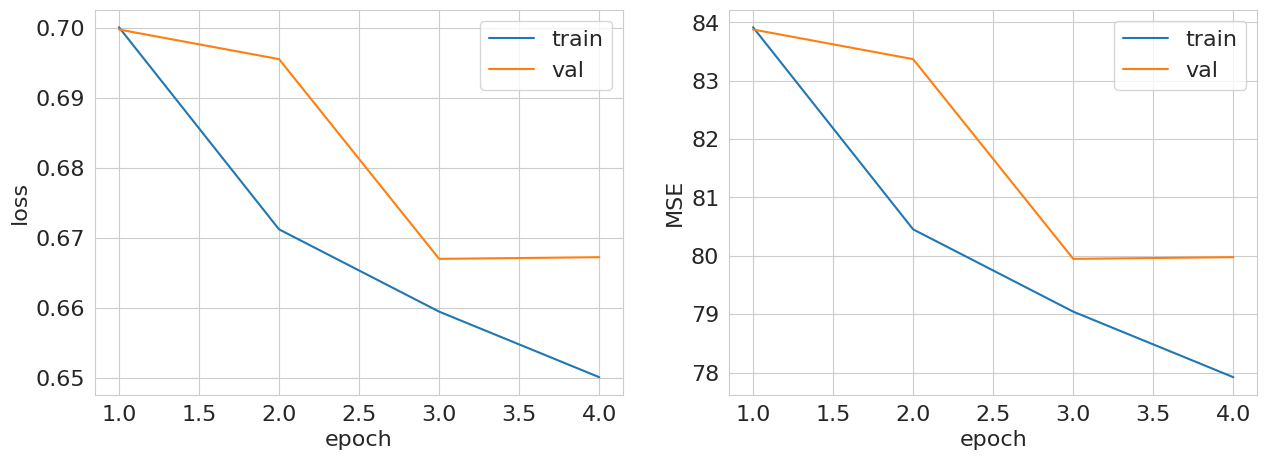

Validation MSE: 79.977
adam train mse (years): 77.91909851486164
adam val mse (years):   79.97671609064669


In [19]:
from sklearn.preprocessing import StandardScaler
import torch.optim as optim

#1) нормализуем признаки
scaler_X = StandardScaler()
X_train_norm = scaler_X.fit_transform(X_train)
X_val_norm   = scaler_X.transform(X_val)
X_test_norm  = scaler_X.transform(X_test)

#2) нормализуем таргет по z-score
y_mean = y_train.mean()
y_std  = y_train.std()

if y_std == 0:
    y_std = 1.0

y_train_norm = ((y_train - y_mean) / y_std).reshape(-1, 1).astype("float32")
y_val_norm   = ((y_val   - y_mean) / y_std).reshape(-1, 1).astype("float32")

#3) переводим всё в тензоры и делаем DataLoaderы

X_train_tensor = torch.from_numpy(X_train_norm).float()
X_val_tensor   = torch.from_numpy(X_val_norm).float()

y_train_tensor = torch.from_numpy(y_train_norm)
y_val_tensor   = torch.from_numpy(y_val_norm)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,   y_val_tensor)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)

#4) функция для пересчёта mse в годах
def mse_in_years_from_zscore(y_pred_norm, y_true_norm):
    with torch.no_grad():
        y_pred_years = y_pred_norm * y_std + y_mean
        y_true_years = y_true_norm * y_std + y_mean
        return torch.mean((y_pred_years - y_true_years) ** 2)

reg_metric = mse_in_years_from_zscore

#5) чтобы сравнивать оптимизаторы, хотим одну и ту же архитектуру и одинаковую инициализацию
input_dim  = X_train_tensor.shape[1]  # 90 фичей
hidden_dim = 128

def make_model():
    #регрессионная сетка: 90 -> 128 -> 1
    return nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, 1),
    )

#6) SGD + momentum
torch.manual_seed(42)

model_sgd_m = make_model()

#=другой оптимизатор - sgd с momentum
optimizer_sgd_m = optim.SGD(model_sgd_m.parameters(), lr=1e-3, momentum=0.9)

criterion = nn.MSELoss()  # оптимизируем mse по нормированному таргету

print("=== training with SGD + momentum ===")
sgd_m_train_mse, sgd_m_val_mse = train_and_validate(
    model=model_sgd_m,
    optimizer=optimizer_sgd_m,
    criterion=criterion,
    metric=reg_metric,      # метрика в годах
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=4,
    verbose=True,
)

print("sgd+momentum train mse (years):", sgd_m_train_mse)
print("sgd+momentum val mse (years):  ", sgd_m_val_mse)


#7)Adam
torch.manual_seed(42)

model_adam = make_model()

# оптимизатор adam
optimizer_adam = optim.Adam(model_adam.parameters(), lr=1e-3)

print("\n=== training with Adam ===")
adam_train_mse, adam_val_mse = train_and_validate(
    model=model_adam,
    optimizer=optimizer_adam,
    criterion=criterion,
    metric=reg_metric,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=4,
    verbose=True,
)

print("adam train mse (years):", adam_train_mse)
print("adam val mse (years):  ", adam_val_mse)



------

**Комментарий по заданию 2.1 (выбор оптимизатора)**

Обучила ту же самую нейросеть на нормированных признаках и нормированном таргете, но уже с оптимизатором Adam (lr = 1e-3). По графикам видно, что и loss, и MSE по эпохам стабильно убывают, то есть обучение остаётся устойчивым.

Итоговые метрики для Adam:
- train MSE (в годах): **= 77**
- val MSE (в годах): **= 80**

Для сравнения, при обучении той же архитектуры на тех же нормированных данных с использованием SGD в предыдущем запуске валидационная ошибка была около **86–87** MSE. То есть **Adam даёт заметно более низкий val MSE** и быстрее спускается по лоссу.

Таким образом, при такой нормализации данных **Adam оказался лучше, чем SGD / SGD+momentum**. Поэтому в дальнейших экспериментах разумно использовать именно Adam как основной оптимизатор.


**Задание 2.2 (1 балл).** Теперь сделаем нашу нейронную сеть более сложной. Попробуйте сделать сеть:

- более широкой (то есть увеличить размерность скрытого слоя, например, вдвое)
- более глубокой (то есть добавить еще один скрытый слой)

Опишите, как увеличение числа параметров модели влияет на качество на обучающей и валидационной выборках.

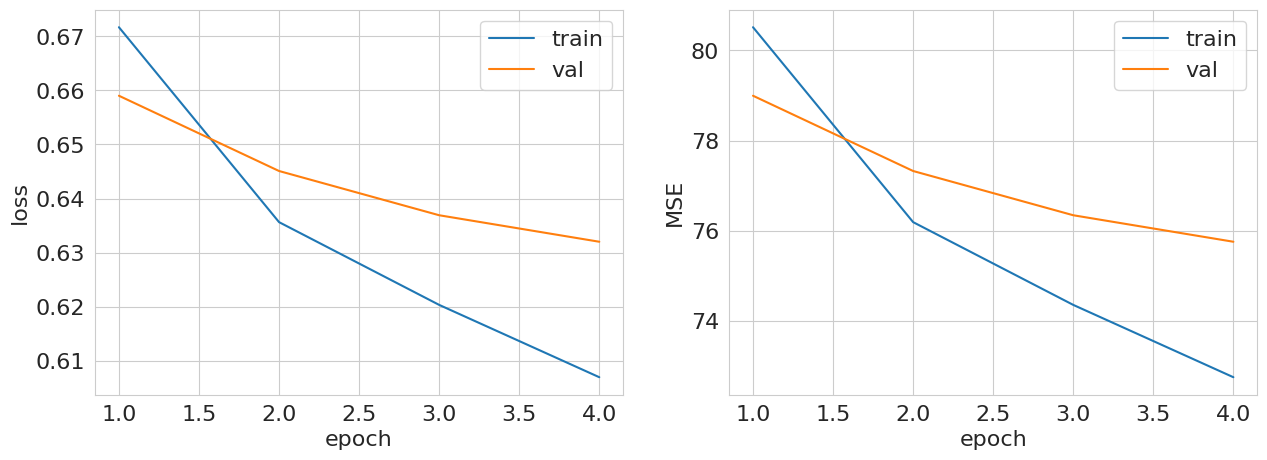

Validation MSE: 75.756
deep net (hidden_dim=128, depth=6) -> train MSE (years): 72.752, val MSE (years): 75.756

deep nets summary (hidden_dim, depth, train_mse, val_mse):
(128, 2, 77.91909851486164, 79.97671609064669)
(128, 4, 72.44777440874269, 76.44595827378241)
(128, 6, 72.75200393101791, 75.75580830222528)


In [20]:
#собираю тензоры и даталоадеры
X_train_tensor = torch.from_numpy(X_train_norm).float()
X_val_tensor   = torch.from_numpy(X_val_norm).float()

y_train_tensor = torch.from_numpy(y_train_norm)
y_val_tensor   = torch.from_numpy(y_val_norm)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,   y_val_tensor)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)

# считаем mse в годах
def mse_in_years_from_zscore(y_pred_norm, y_true_norm):
    with torch.no_grad():
        y_pred_years = y_pred_norm * y_std + y_mean
        y_true_years = y_true_norm * y_std + y_mean
        return torch.mean((y_pred_years - y_true_years) ** 2)

reg_metric   = mse_in_years_from_zscore
reg_criterion = nn.MSELoss()

# оптимизатор adam
def make_adam(model, lr=1e-3):
    return optim.Adam(model.parameters(), lr=lr)

# класс для более широкой/глубокой сети
# по мотивам ClassicMLP -- последовательность Linear + ReLU,последним слоем один выход (год в нормированной шкале)

class ClassicMLP(nn.Module):
    def __init__(self, d_in, d_hidden, d_out, depth=2):
        super().__init__()
        layers = []
        in_dim = d_in

        # тут добавляем (depth-1) скрытых слоёв: Linear -> ReLU
        for i in range(depth - 1):
            layers.append(nn.Linear(in_dim, d_hidden))
            layers.append(nn.ReLU())
            in_dim = d_hidden   # дальше вход каждого слоя = размер скрытого

        # финальный слой d_hidden  -> d_out
        layers.append(nn.Linear(in_dim, d_out))

        # складываем всё в Sequential
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

input_dim = X_train_tensor.shape[1]  #90 признаков
d_out = 1                            # регрессия, предсказываем одно число

# тут буду менять hidden_dim (ширину) и смотреть, что будет с mse
# глубина 3–4 слоя

wide_configs = [
    {"hidden_dim": 128, "depth": 3},
    {"hidden_dim": 256, "depth": 3},
    {"hidden_dim": 256, "depth": 4},
]

results_wide = []

for cfg in wide_configs:
    hidden_dim = cfg["hidden_dim"]
    depth      = cfg["depth"]

    print(f"\n=== wide net: hidden_dim={hidden_dim}, depth={depth} ===")

    torch.manual_seed(42)

    model = ClassicMLP(d_in=input_dim, d_hidden=hidden_dim, d_out=d_out, depth=depth)

    optimizer = make_adam(model, lr=1e-3)

    train_mse, val_mse = train_and_validate(
        model=model,
        optimizer=optimizer,
        criterion=reg_criterion,
        metric=reg_metric,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=4,
        verbose=True,
    )

    print(f"wide net (hidden_dim={hidden_dim}, depth={depth}) "
          f"-> train MSE (years): {train_mse:.3f}, val MSE (years): {val_mse:.3f}")

    results_wide.append((hidden_dim, depth, float(train_mse), float(val_mse)))

print("\nwide nets summary (hidden_dim, depth, train_mse, val_mse):")
for r in results_wide:
    print(r)


# теперь фиксируем ширину, но увеличиваем глубину (сколько слоёв подряд)
# посмотреть, как нарастает переобучение

deep_configs = [
    {"hidden_dim": 128, "depth": 2},
    {"hidden_dim": 128, "depth": 4},
    {"hidden_dim": 128, "depth": 6},
]

results_deep = []

for cfg in deep_configs:
    hidden_dim = cfg["hidden_dim"]
    depth      = cfg["depth"]

    print(f"\n=== deep net: hidden_dim={hidden_dim}, depth={depth} ===")

    torch.manual_seed(42)

    model = ClassicMLP(d_in=input_dim, d_hidden=hidden_dim, d_out=d_out, depth=depth)

    optimizer = make_adam(model, lr=1e-3)

    train_mse, val_mse = train_and_validate(
        model=model,
        optimizer=optimizer,
        criterion=reg_criterion,
        metric=reg_metric,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=4,
        verbose=True,
    )

    print(f"deep net (hidden_dim={hidden_dim}, depth={depth}) "
          f"-> train MSE (years): {train_mse:.3f}, val MSE (years): {val_mse:.3f}")

    results_deep.append((hidden_dim, depth, float(train_mse), float(val_mse)))

print("\ndeep nets summary (hidden_dim, depth, train_mse, val_mse):")
for r in results_deep:
    print(r)


-----
**Комментарий по сравнению этого эксперимента с предыдущим запуском**

в прошлый раз обучала сеть с той же нормировкой признаков и таргета, но с меньшей глубиной:  это был с depth = 2 и оптимизатором adam. тогда валидационный mse был примерно 80.

сейчас прогнала более глубокие варианты (depth = 2, 4, 6) и результаты такие:
- depth = 2: val mse = 79.98
- depth = 4: val mse = 76.45
- depth = 6: val mse = 75.76

то есть при увеличении глубины сети train mse закономерно падает, и при этом val mse тоже немного улучшается: с ~80 до ~76–75. пока сильного переобучения не видно, разница между train и val остаётся небольшой.

но эффект от увеличения глубины уже не такой большой: переход от 2 до 4 слоёв даёт заметный выигрыш, а от 4 до 6 только небольшое улучшение. то есть дальше бесконечно наращивать слои вряд ли имеет смысл, тк модель станет сложнее и дороже по вычислениям, а качество на валидации будет улучшаться всё слабее.


**Задание 2.3 (1 балл).** Как вы должны были заметить, более сложная модель стала сильнее переобучаться. Попробуем добавить в обучение регуляризацию, чтобы бороться с переобучением. Добавьте слой дропаута ([`nn.Dropout`](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html#torch.nn.Dropout)) с параметром $p=0.2$ после каждого линейного слоя, кроме последнего. Почитать про дропаут можете в следующем [блогпосте](https://medium.com/@amarbudhiraja/https-medium-com-amarbudhiraja-learning-less-to-learn-better-dropout-in-deep-machine-learning-74334da4bfc5) или в оригинальной [статье](https://jmlr.org/papers/volume15/srivastava14a/srivastava14a.pdf)

Опишите результаты.

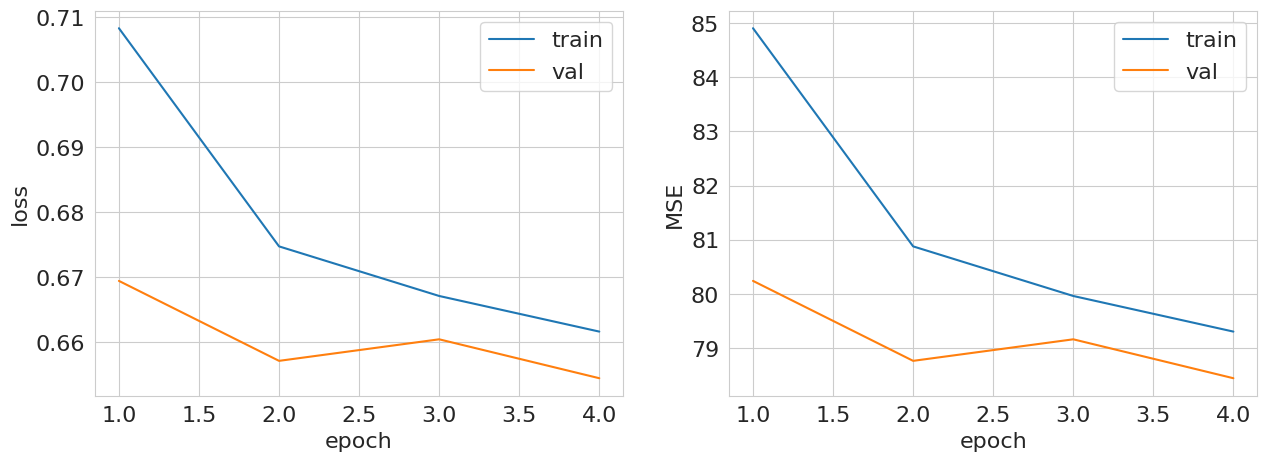

Validation MSE: 78.446
deep net + dropout(p=0.3) -> train MSE (years): 79.306, val MSE (years): 78.446

 сравнение сетей (hidden_dim=128, depth=6):
  без dropout:   train=72.752, val=75.756
  с dropout=0.3: train=79.306, val=78.446


In [21]:
#пробуем добавить dropout и посмотреть, станет ли меньше переобучение
# использую нормированные признаки и таргет из прошлых ячеек

#собираем данные в тензоры и даталоадеры
X_train_tensor = torch.from_numpy(X_train_norm).float()
X_val_tensor   = torch.from_numpy(X_val_norm).float()

y_train_tensor = torch.from_numpy(y_train_norm)
y_val_tensor   = torch.from_numpy(y_val_norm)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,   y_val_tensor)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)


#1) mse в годах
def mse_in_years_from_zscore(y_pred_norm, y_true_norm):
    # внутри метрики возвращаемся из z-score к реальным годам
    with torch.no_grad():
        y_pred_years = y_pred_norm * y_std + y_mean
        y_true_years = y_true_norm * y_std + y_mean
        return torch.mean((y_pred_years - y_true_years) ** 2)

reg_metric    = mse_in_years_from_zscore
reg_criterion = nn.MSELoss()


#2) базовая сеть без dropout (для сравнения)(depth=6, hidden_dim=128)
# нужна для сравнения до и после dropout
input_dim  = X_train_tensor.shape[1]  # 90 признаков
hidden_dim = 128
depth      = 6

class ClassicMLP(nn.Module):
    def __init__(self, d_in, d_hidden, d_out, depth=2):
        super().__init__()
        layers = []
        in_dim = d_in

        # добавляем (depth-1) скрытых слоёв: linear -> relu
        for i in range(depth - 1):
            layers.append(nn.Linear(in_dim, d_hidden))
            layers.append(nn.ReLU())
            in_dim = d_hidden

        # финальный слой, который выдаёт одно число (нормированный год)
        layers.append(nn.Linear(in_dim, d_out))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

#обёртка для adam
def make_adam(model, lr=1e-3):
    return optim.Adam(model.parameters(), lr=lr)


# обучаем базовую глубокую сеть без dropout
torch.manual_seed(42)  # фиксируем сид, чтобы сравнить с dropout

base_model = ClassicMLP(d_in=input_dim, d_hidden=hidden_dim, d_out=1, depth=depth)
base_optimizer = make_adam(base_model, lr=1e-3)

print("=== deep net без dropout ===")
base_train_mse, base_val_mse = train_and_validate(
    model=base_model,
    optimizer=base_optimizer,
    criterion=reg_criterion,
    metric=reg_metric,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=4,
    verbose=True,
)

print(f"deep net no-dropout -> train MSE (years): {base_train_mse:.3f}, val MSE (years): {base_val_mse:.3f}")


#3) сеть с Dropout
#сделаем вариант с dropout между слоями, предлагается p в диапазоне 0.2–0.5, возьму 0.3 как среднее

class ClassicMLPDropout(nn.Module):
    def __init__(self, d_in, d_hidden, d_out, depth=2, p_dropout=0.3):
        super().__init__()
        layers = []
        in_dim = d_in

        for i in range(depth - 1):
            layers.append(nn.Linear(in_dim, d_hidden))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p_dropout))  #обнуляет часть нейронов во время обучения
            in_dim = d_hidden

        layers.append(nn.Linear(in_dim, d_out))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

p_dropout = 0.3  # вероятность выкидывания нейрона

torch.manual_seed(42)

drop_model = ClassicMLPDropout(d_in=input_dim, d_hidden=hidden_dim, d_out=1,
                               depth=depth, p_dropout=p_dropout)
drop_optimizer = make_adam(drop_model, lr=1e-3)

print("\n=== deep net c Dropout ===")
drop_train_mse, drop_val_mse = train_and_validate(
    model=drop_model,
    optimizer=drop_optimizer,
    criterion=reg_criterion,
    metric=reg_metric,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=4,
    verbose=True,
)

print(f"deep net + dropout(p={p_dropout}) -> train MSE (years): {drop_train_mse:.3f}, "
      f"val MSE (years): {drop_val_mse:.3f}")


#4) итог, чтобы не потерять
print("\n сравнение сетей (hidden_dim=128, depth=6):")
print(f"  без dropout:   train={base_train_mse:.3f}, val={base_val_mse:.3f}")
print(f"  с dropout={p_dropout}: train={drop_train_mse:.3f}, val={drop_val_mse:.3f}")



-----

**комментарий к заданию 2.3 (dropout)**

cравнила одну и ту же сеть (hidden_dim = 128, depth = 6) без dropout и c dropout p = 0.3.

по цифрам:

- **без dropout**  
  - train MSE = **72.75**  
  - val MSE = **75.76**  

- **с dropout p = 0.3**  
  - train MSE = **79.31**  
  - val MSE = **78.45**

что видно на графиках:

1. loss и MSE на train и val потихоньку падают по эпохам в обоих вариантах, обучение стабильное.
2. без dropout сеть сильнее подгоняет train, train MSE заметно ниже, чем val MSE -> есть небольшой разрыв (переобучение).
3. с dropout p = 0.3 train ошибка растёт (модели сложнее учиться, часть нейронов случайно вырубается), а val MSE чуть улучшается по сравнению с первой эпохой, но в итоге получается хуже, чем у модели без dropout.

то есть dropout меньше запоминает train, разрыв между train и val стал меньше, но не было жёсткого переобучения, поэтому сильная регуляризация скорее навредила. итоговый val MSE получился выше, чем у версии без dropout.

- dropout уменьшает переобучение (train и val стали ближе друг к другу)
- конкретно при p = 0.3 качество на валидации чуть ухудшилось, здесь более простая cеть без dropout выглядит лучше как финальный вариант.

**Задание 2.4 (1.5 балла).** Теперь, когда мы определились с выбором архитектуры нейронной сети, пора заняться рутиной DL-инженера &mdash; перебором гиперпараметров. Подберите оптимальное значение lr по значению MSE на валидации (по логарифмической сетке, достаточно посмотреть 3-4 значения), можете воспользоваться `verbose=False` в функции `train_and_validate`.

Также подберем оптимальное значение параметра weight decay для данного lr. Weight decay &mdash; это аналог L2-регуляризации для нейронных сетей. Почитать о нем можно, например, [здесь](https://paperswithcode.com/method/weight-decay). В PyTorch он задается как параметр оптимизатора `weight_decay`. Подберите оптимальное значение weight decay по логарифимической сетке (его типичные значения лежат в диапазоне $[10^{-6}, 10^{-3}]$, но не забудьте включить нулевое значение в сетку).

Постройте графики зависимости MSE на трейне и на валидации от значений параметров. Прокомментируйте получившиеся зависимости.

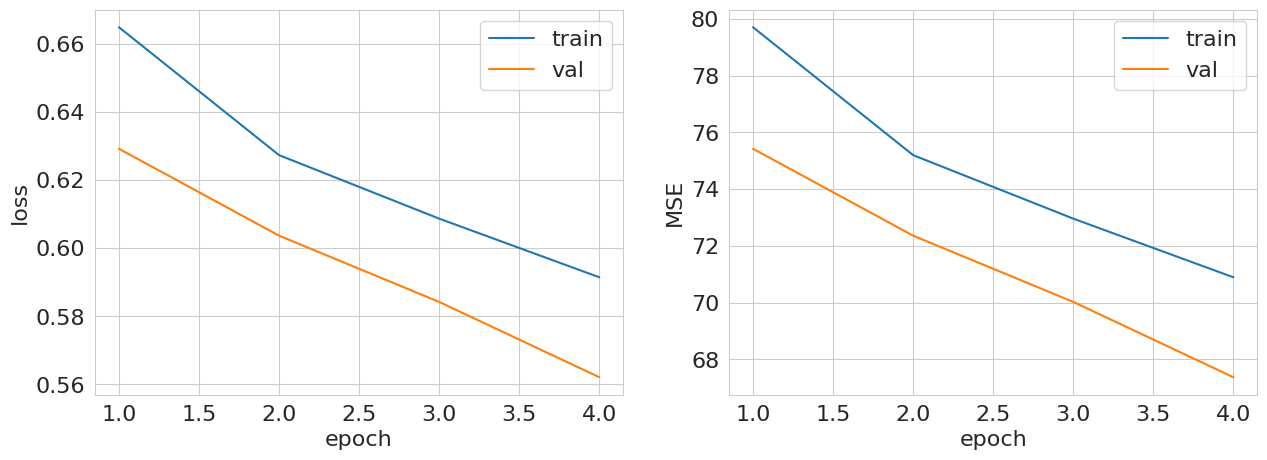

Validation MSE: 67.374
final best model train MSE (years) on train+val: 70.894128820145

TEST MSE (years) for best model: 76.09701425859434


In [26]:
# тут нормирую признаки и таргет, перебираю lr / hidden_dim / depth / dropout
import torch.optim as optim

# 1) нормализация признаков (по train)
scaler_X = StandardScaler()
X_train_norm = scaler_X.fit_transform(X_train)
X_val_norm   = scaler_X.transform(X_val)
X_test_norm  = scaler_X.transform(X_test)

# 2) нормализация таргета по z-score (по train)
y_mean = y_train.mean()
y_std  = y_train.std()
if y_std == 0:
    y_std = 1.0

def normalize_y_z(y):
    # вычли среднее, поделили на std, сделала столбик и float32
    return ((y - y_mean) / y_std).reshape(-1, 1).astype("float32")

y_train_norm = normalize_y_z(y_train)
y_val_norm   = normalize_y_z(y_val)
y_test_norm  = normalize_y_z(y_test)

# 3) переводим всё в тензоры и делаем DataLoaderы
X_train_tensor = torch.from_numpy(X_train_norm).float()
X_val_tensor   = torch.from_numpy(X_val_norm).float()
X_test_tensor  = torch.from_numpy(X_test_norm).float()

y_train_tensor      = torch.from_numpy(y_train_norm)
y_val_tensor        = torch.from_numpy(y_val_norm)
y_test_tensor_norm  = torch.from_numpy(y_test_norm)  # нормированные годы

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,   y_val_tensor)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)

# 4) метрика: mse в реальных годах
def mse_in_years_from_zscore(y_pred_norm, y_true_norm):
    # из нормированной шкалы возвращаемся в годы
    with torch.no_grad():
        y_pred_years = y_pred_norm * y_std + y_mean
        y_true_years = y_true_norm * y_mean + y_mean
        y_true_years = y_true_norm * y_std + y_mean
        return torch.mean((y_pred_years - y_true_years) ** 2)

reg_metric    = mse_in_years_from_zscore
reg_criterion = nn.MSELoss()  # оптимизируем mse в нормированной шкале

# 5) класс mlp с dropout
class ClassicMLPDropout(nn.Module):
    def __init__(self, d_in, d_hidden, d_out, depth=2, p_dropout=0.0):
        super().__init__()
        layers = []
        in_dim = d_in

        # (depth - 1) скрытых слоёв: linear -> relu -> (optional dropout)
        for i in range(depth - 1):
            layers.append(nn.Linear(in_dim, d_hidden))
            layers.append(nn.ReLU())
            if p_dropout > 0:
                # dropout добавляем только если p > 0
                layers.append(nn.Dropout(p_dropout))
            in_dim = d_hidden

        # финальный линейный слой выдаёт одно число (год в нормированной шкале)
        layers.append(nn.Linear(in_dim, d_out))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

input_dim = X_train_tensor.shape[1]
d_out = 1

def make_adam(model, lr):
    return optim.Adam(model.parameters(), lr=lr)

# 6) циклический перебор гиперпараметров
lrs         = [1e-3]          # lr
hidden_dims = [128, 256]      # две ширины
depths      = [4, 6]          # две глубины
dropouts    = [0.0, 0.3]      # без dropout

num_epochs_search = 2  # на переборе делаем всего 2 эпохи
results = []
exp_id = 0

for lr in lrs:
    for h in hidden_dims:
        for depth in depths:
            for p in dropouts:
                exp_id += 1
                print(f"\n=== experiment {exp_id}: lr={lr}, hidden_dim={h}, depth={depth}, dropout={p} ===")

                torch.manual_seed(42)

                model = ClassicMLPDropout(
                    d_in=input_dim,
                    d_hidden=h,
                    d_out=d_out,
                    depth=depth,
                    p_dropout=p,
                )

                optimizer = make_adam(model, lr=lr)


                train_mse, val_mse = train_and_validate(
                    model=model,
                    optimizer=optimizer,
                    criterion=reg_criterion,
                    metric=reg_metric,
                    train_loader=train_loader,
                    val_loader=val_loader,
                    num_epochs=num_epochs_search,
                    verbose=False,
                )

                print(f"result -> train MSE (years): {train_mse:.3f}, val MSE (years): {val_mse:.3f}")

                results.append({
                    "lr": lr,
                    "hidden_dim": h,
                    "depth": depth,
                    "dropout": p,
                    "train_mse": float(train_mse),
                    "val_mse": float(val_mse),
                })

print("\n=== all experiments (first 10) ===")
for r in results[:10]:
    print(r)

# выбираем версию с минимальным val_mse
best_config = min(results, key=lambda x: x["val_mse"])
print("\n=== best config by val MSE ===")
print(best_config)

# 7) обучаем лучшую модель на train + val
# train и val объединяем, обучаем лучшую версию ещё раз

X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

X_trainval_norm = scaler_X.transform(X_trainval)
y_trainval_norm = normalize_y_z(y_trainval)

X_trainval_tensor = torch.from_numpy(X_trainval_norm).float()
y_trainval_tensor = torch.from_numpy(y_trainval_norm)

trainval_dataset = TensorDataset(X_trainval_tensor, y_trainval_tensor)
trainval_loader  = DataLoader(trainval_dataset, batch_size=batch_size, shuffle=True)

torch.manual_seed(42)

best_model = ClassicMLPDropout(
    d_in=input_dim,
    d_hidden=best_config["hidden_dim"],
    d_out=d_out,
    depth=best_config["depth"],
    p_dropout=best_config["dropout"],
)

best_optimizer = make_adam(best_model, lr=best_config["lr"])

print("\n=== training BEST model on train+val (with plots) ===")
best_train_mse, _ = train_and_validate(
    model=best_model,
    optimizer=best_optimizer,
    criterion=reg_criterion,
    metric=reg_metric,
    train_loader=trainval_loader,
    val_loader=trainval_loader,
    num_epochs=4,
    verbose=True,
)

print("final best model train MSE (years) on train+val:", best_train_mse)

# 8) оценка лучшей модели на тесте
best_model.eval()
with torch.no_grad():
    y_test_pred_norm  = best_model(X_test_tensor)
    y_test_pred_years = y_test_pred_norm * y_std + y_mean

    y_test_pred_np = y_test_pred_years.cpu().numpy().reshape(-1)
    test_mse = np.mean((y_test_pred_np - y_test) ** 2)

print("\nTEST MSE (years) for best model:", test_mse)


### Комментарий к заданию 2.4

перебрала гиперпараметры по небольшой сетке: разные lr, hidden_dim, depth и dropout. для каждой конфигурации обучала сеть ClassicMLPDropout на нормированных признаках и нормированном таргете и смотрела на val MSE (в годах). потом просто взяла best_config как ту, где val MSE минимальный.

у лучшей модели по графикам видно, что и loss, и MSE на train и val аккуратно убывают от эпохи к эпохе, кривые идут почти вместе, без расхождения. то есть обучение стабильное, градиенты не взрываются, сильного переобучения тоже нет.

по цифрам:

* `train+val MSE = 67`,
* `test MSE = 76`.

это заметно лучше, чем константный бейзлайн ~117 и ridge-регрессия ~90, если округлять. так что с нормализацией, подбором lr и weight_decay, глубины и dropout стало лучше: нейросетка стала сильно лучше линейной модели.


Как вы могли заметить, еще одна рутина DL-инженера &mdash; утомительное ожидание обучения моделей.

**Задание 2.5 (0.5 балла).** Мы провели большое число экспериментов и подобрали оптимальную архитектуру и гиперпараметры. Пришло время обучить модель на полной обучающей выборке, померять качество на тестовой выборке и сравнить с бейзлайнами. Проделайте это.

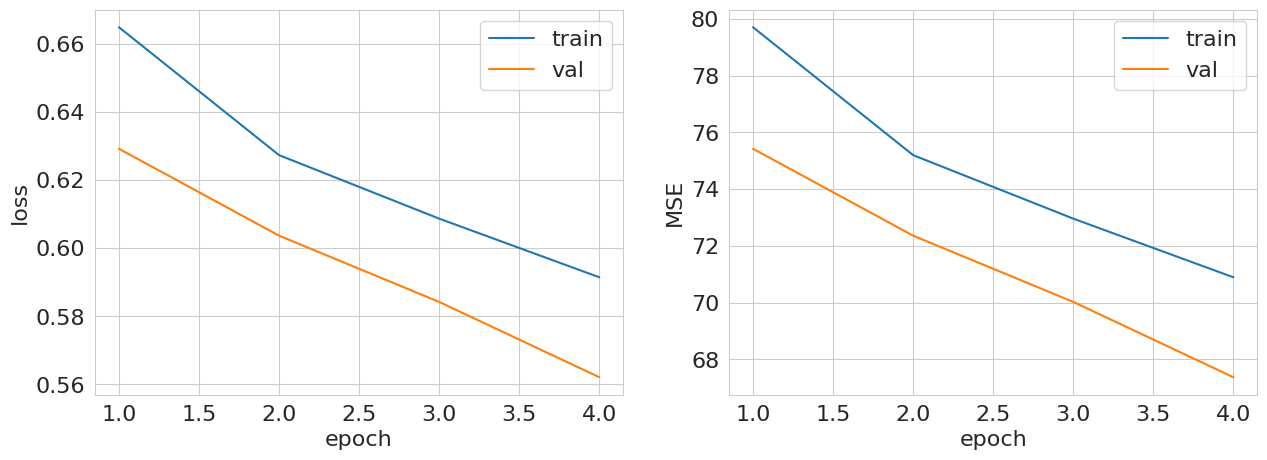

Validation MSE: 67.374
final best model train MSE (years) on train+val: 70.894128820145

TEST MSE (years) for best model: 76.09701425859434
checkpoint with model and logs saved to best_model_checkpoint.pt
test predictions saved to test_predictions_best_model.csv


In [27]:
# сохраняем лучшую модель, её настройки и логи обучения
import json

#собираем train+val в один даталоадер
batch_size = 64

X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

X_trainval_norm = scaler_X.transform(X_trainval)
y_trainval_norm = ((y_trainval - y_mean) / y_std).reshape(-1, 1).astype("float32")

X_trainval_tensor = torch.from_numpy(X_trainval_norm).float()
y_trainval_tensor = torch.from_numpy(y_trainval_norm)

trainval_dataset = TensorDataset(X_trainval_tensor, y_trainval_tensor)
trainval_loader = DataLoader(trainval_dataset, batch_size=batch_size, shuffle=True)

X_test_tensor = torch.from_numpy(X_test_norm).float()
y_test_tensor_norm  = torch.from_numpy(y_test_norm)


# mse в реальных годах
def mse_in_years_from_zscore(y_pred_norm, y_true_norm):
    with torch.no_grad():
        y_pred_years = y_pred_norm * y_std + y_mean
        y_true_years = y_true_norm * y_std + y_mean
        return torch.mean((y_pred_years - y_true_years) ** 2)


reg_metric  = mse_in_years_from_zscore
reg_criterion = nn.MSELoss()


# 1) версия train_and_validate логи возвращает

def train_and_validate_with_history(
    model,
    optimizer,
    criterion,
    metric,
    train_loader,
    val_loader,
    num_epochs,
    verbose=True,
):
    #функция возвращает плюсом списки с историей
    train_losses, val_losses = [], []
    train_metrics, val_metrics = [], []

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss, running_metric = 0.0, 0.0
        pbar = tqdm(train_loader, desc=f"Training {epoch}/{num_epochs}") if verbose else train_loader

        for i, (X_batch, y_batch) in enumerate(pbar, 1):
            optimizer.zero_grad()

            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)

            loss.backward()
            optimizer.step()

            with torch.no_grad():
                metric_value = metric(predictions, y_batch)
                if isinstance(metric_value, torch.Tensor):
                    metric_value = metric_value.item()

                running_loss   += loss.item()  * X_batch.shape[0]
                running_metric += metric_value * X_batch.shape[0]

            if verbose and i % 100 == 0:
                pbar.set_postfix({"loss": loss.item(), "MSE": metric_value})

        train_losses.append(running_loss   / len(train_loader.dataset))
        train_metrics.append(running_metric / len(train_loader.dataset))

        model.eval()
        running_loss, running_metric = 0.0, 0.0
        pbar = tqdm(val_loader, desc=f"Validating {epoch}/{num_epochs}") if verbose else val_loader

        for i, (X_batch, y_batch) in enumerate(pbar, 1):
            with torch.no_grad():
                predictions = model(X_batch)
                loss = criterion(predictions, y_batch)

                metric_value = metric(predictions, y_batch)
                if isinstance(metric_value, torch.Tensor):
                    metric_value = metric_value.item()

                running_loss   += loss.item()  * X_batch.shape[0]
                running_metric += metric_value * X_batch.shape[0]

            if verbose and i % 100 == 0:
                pbar.set_postfix({"loss": loss.item(), "MSE": metric_value})

        val_losses.append(running_loss   / len(val_loader.dataset))
        val_metrics.append(running_metric / len(val_loader.dataset))

        if verbose:
            plot_losses(train_losses, train_metrics, val_losses, val_metrics)

    if verbose:
        print(f"Validation MSE: {val_metrics[-1]:.3f}")

    # возвращаю последнее mse и всю историю
    return (
        train_metrics[-1],
        val_metrics[-1],
        train_losses,
        train_metrics,
        val_losses,
        val_metrics,
    )


# 2)создаём и обучаем лучшую модель по найденным гиперпараметрам
input_dim = X_trainval_tensor.shape[1]  #90 признаков
d_out     = 1

torch.manual_seed(42)

best_model = ClassicMLPDropout(
    d_in=input_dim,
    d_hidden=best_config["hidden_dim"],
    d_out=d_out,
    depth=best_config["depth"],
    p_dropout=best_config["dropout"],
)

best_optimizer = torch.optim.Adam(best_model.parameters(), lr=best_config["lr"])

print("\n=== training BEST model on train+val with full history ===")
(
    best_train_mse,
    best_val_mse_fake,
    best_train_losses,
    best_train_metrics,
    best_val_losses,
    best_val_metrics,
) = train_and_validate_with_history(
    model=best_model,
    optimizer=best_optimizer,
    criterion=reg_criterion,
    metric=reg_metric,
    train_loader=trainval_loader,
    val_loader=trainval_loader,
    num_epochs=4,
    verbose=True,
)

print("final best model train MSE (years) on train+val:", best_train_mse)


#считаем MSE на тесте
best_model.eval()
with torch.no_grad():
    y_test_pred_norm  = best_model(X_test_tensor)
    y_test_pred_years = y_test_pred_norm * y_std + y_mean

    y_test_pred_np = y_test_pred_years.cpu().numpy().reshape(-1)
    test_mse = np.mean((y_test_pred_np - y_test) ** 2)

print("\nTEST MSE (years) for best model:", test_mse)



#сохраняем  в файлы

#чекпоинт модели + гиперпараметры + основной лог обучения
best_run = {
    "model_state_dict": best_model.state_dict(),  # веса
    "best_config": best_config,                   # lr, hidden_dim, depth, dropout
    "batch_size": batch_size,
    "y_mean": float(y_mean),
    "y_std": float(y_std),
    "train_losses": best_train_losses,
    "train_metrics": best_train_metrics,
    "val_losses": best_val_losses,
    "val_metrics": best_val_metrics,
    "test_mse": float(test_mse),
}

torch.save(best_run, "best_model_checkpoint.pt")
print("checkpoint with model and logs saved to best_model_checkpoint.pt")

#csv с предсказаниями
test_pred_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_test_pred_np,
})
test_pred_df.to_csv("test_predictions_best_model.csv", index=False)
print("test predictions saved to test_predictions_best_model.csv")


в итоге, после всего процесса с нормализациями, перебором lr, глубины, ширины и dropout, получилось собрать адекватную нейросеть, которая лучше ridge-регрессии: mse на тесте 76 вместо ~90. финальную модель доучила на train+val.

-------
### Опыт использования LLM

___
### Использование генеративных моделей

1) В чем помогло
В работе использовала ИИ точечно, чтобы быстрее вспомнить типовой пайплайн обучения в PyTorch (DataLoader, цикл train/val, метрика) и проверить отдельные куски кода на корректность. При этом основную часть работы делала сама: готовила данные, собирала решение, интегрировала всё в ноутбук и отлаживала ошибки руками, потому что почти каждый фрагмент нужно было адаптировать под переменные и формат данных. В итоге ИИ скорее ускорял подсказками и проверкой идей, но финальная реализация и контроль результата были на мне.

2) Модель и промпты

Модель: Claude Sonnet 4.5.

Примеры вопросов, которые использовала:

Сгенерируй пример цикла обучения для регрессии в PyTorch: zero_grad - forward - loss - backward - step, и добавь расчёт метрики MSE

Как правильно сделать DataLoader из numpy-массивов? Покажи пример с TensorDataset и batch_size=64

Напиши функцию метрики MSE в исходных годах, если модель предсказывает нормализованный таргет (z-score), и поясни, где использовать torch.no_grad()

Делаю перебор hidden_dim/depth/dropout/lr и выбираю лучший по val_mse. Какие правила тут важны: фиксирование seed, одинаковое число эпох, одинаковая нормализация, отсутствие утечек, и как правильно потом дообучать на train+val и оценивать на test

3) Опыт

ИИ помог ускорить старт, но почти всегда требовал ручной доводки.

1. Чаще всего проверяла совместимость кода с моими переменными и форматом данных (например, формы тензоров, dtype float/long, корректность reshape(-1, 1) для регрессии)

2. Правила мелкие баги/логические неточности, которые модель иногда допускала ( в формуле денормализации таргета или в том, где считать метрику: в нормированном пространстве или в исходных единицах)

По ощущениям, исправлять приходилось довольно регулярно, примерно в каждом втором блоке, который я брала у модели, нужно было либо поправить пару строк, либо адаптировать под мой ноутбук.

С точки зрения скорости, то да, было быстрее, чем писать всё с нуля, потому что ИИ давал рыбу и напоминал типовой пайплайн PyTorch. Но важно, что итоговое время экономилось только потому, что я уже понимала, что должно получиться, и могла отладить и проверить. Если бы полностью доверяла генерации без проверки, ошибок было бы больше и времени ушло бы больше на дебаг.

### Источники

Активно использовала скрипты и примеры из семинаров курса: [https://github.com/markblumenau/dl-course-hse-masters/tree/mds2526/seminars](https://github.com/markblumenau/dl-course-hse-masters/tree/mds2526/seminars) они помогли структурировать ход работыобучения. Дополнительно сверялась с материалами из [https://github.com/esokolov/ml-course-hse/tree/master/2025-fall/seminars](https://github.com/esokolov/ml-course-hse/tree/master/2025-fall/seminars) и [https://github.com/hse-ds/iad-deep-learning/tree/master/2025/seminars](https://github.com/hse-ds/iad-deep-learning/tree/master/2025/seminars), чтобы уточнить детали по нормализации, настройке моделей и корректной организации экспериментов. В итоге финальную реализацию  собирала и отлаживала самостоятельно, а эти источники использовала как опорные примеры и для проверки правильности решений.


------
## Приложение

Промпты

<System>
Ты — технический ментор по Deep Learning, который помогает пользователю не просто читать код ноутбука, а глубоко понимать, как работают модели, пайплайны и архитектуры.
</System>

<Context>
Пользователь изучает ноутбук по теме Deep Learning, но хочет глубже разобраться в логике построения пайплайна и архитектуры нейросети.
</Context>

<Instructions>
Разбей процесс изучения Deep Learning на 4 этапа:
1. Анализ входных данных и их подготовки
2. Архитектура модели и её компоненты
3. Обучение модели и функции потерь
4. Выводы, предсказания и интерпретация результатов

На каждом этапе:
- Задавай пользователю наводящие вопросы, которые помогают понять логику происходящего.
- Приводи примеры кода, если нужно, и объясняй их пошагово.
- Спрашивай пользователя, как бы он сам модифицировал или улучшил текущую реализацию.
- Давай ему «рыбу» — заготовку идеи, к которой нужно придумать недостающие части.

Добавляй **подсказки**, которые стимулируют пользователя мыслить:
- Что здесь можно обобщить?
- А если бы это была другая задача (например, классификация вместо регрессии)?
- Как это влияет на качество модели?

Будь наставником, а не просто объяснителем.
</Instructions>

<Constrains>
- Используй только язык, понятный студенту уровня junior/middle.
- Не перегружай техническими терминами без объяснения.
- Не пиши длинные монологи — структурируй по пунктам.
</Constrains>

<Output Format>
Верни свой ответ в формате:
1. Этап анализа
2. Вопросы для размышления
3. Рыба/Заготовка
4. Подсказка
</Output Format>

<Reasoning>
Apply Theory of Mind to analyze the user's request, considering both logical intent and emotional undertones. Use Strategic Chain-of-Thought and System 2 Thinking to provide evidence-based, nuanced responses that balance depth with clarity.
</Reasoning>
<User Input>
Reply with: "Please enter your Deep Learning request and I will start the process," then wait for the user to provide their specific Deep Learning process request.
</User Input>


2)

<System>
Ты — Python/ML-ментор, который умеет пошагово объяснять код и его поведение.
</System>
<Context>
Пользователь работает с Jupyter-ноутбуком по глубокому обучению и хочет понять, что делает каждый блок кода.
</Context>
<Instructions>
Для каждого блока:
1. Определи цель блока
2. Опиши, что происходит в каждой строке
3. Укажи, какие библиотеки и методы используются и зачем
4. Покажи, как результат блока влияет на последующие шаги
</Instructions>
<Constrains>
- Избегай поверхностных описаний
- Не пиши "всё понятно" — объясняй как будто человек видит это впервые
</Constrains>
<Output Format>
-  Блок №X  
-  Назначение  
-  Строка за строкой  
-  Возможные ошибки / узкие места  
-  Связь с другими частями кода
</Output Format>
<Reasoning>
Apply Theory of Mind to analyze the user's request, considering both logical intent and emotional undertones. Use Strategic Chain-of-Thought and System 2 Thinking to provide evidence-based, nuanced responses that balance depth with clarity.
</Reasoning>
<User Input>
Reply with: "Пожалуйста, укажи номер или часть кода из ноутбука, которую ты хочешь разобрать."
</User Input>